In [2]:
import os
import pandas as pd
import csv
import pickle
import numpy as np
import matplotlib.pyplot as plt
import statistics as stat
import math
import sympy as sym
from sympy import solve

import scipy
from scipy import integrate
from scipy import interpolate
from scipy.optimize import minimize
from scipy.optimize import curve_fit
from scipy.optimize import least_squares 
import pickle
from collections import OrderedDict
from matplotlib.pyplot import cm

from operator import itemgetter

In [3]:
SMALL_SIZE = 8
MEDIUM_SIZE = 14
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [33]:
# Material and root directory
mat = 'Phrozen'
dir = '/Users/mikelapera/Library/CloudStorage/OneDrive-JohnsHopkins/Documents/JHU/Research/Experiments/DMA/data/Phrozen'

# Get master curve from pkl file
fid1 = 'master_curve_Phrozen_90C.pickle'
file1 = os.path.join(dir,fid1)
infile1 = open(file1,'rb')
Ep_isotherm_shifted = pickle.load(infile1)

# Shift factors pkl file
fid2 = 'shift_factors_Phrozen_90C.pickle'
infile2 = open(os.path.join(dir,fid2),'rb')
shift_factors = pickle.load(infile2)  

# Raw DMA data
fid3 = 'Phrozen_DC_35C-160C_cleaned.csv'
filename = os.path.join(dir,fid3)

# Parse tests run at different temperatures using angular frequency patterns
inc = 7 # number of data points taken per temperature

# Universal Gas Constant
R = 8314.5

# Reference temperature (deg. C)
T0 = '90C'

# DMA temperature increments - typically 5 or 10 depending
deg_inc = 5

# DMA angular angular frequency increments
freq_inc = 10

# Number of Prony terms for Prony series - approx. 1 term per decade of master curve
num_prony_terms = 20

# Poisson's ratio (glassy)
nu= 0.34

# Poisson's ratio (rubber)
nu_rubbery = 0.5

# Number of terms for polynomial fit for master curve
num_terms = 15

# Fitting function for mastercuve (spline, exp) - 'exp' option no longer supported
mastercurve_fit_type = 'spline'

# If need to remove data from master curve to improve fitting, set to True
MC_red = False

# Time-Temperature Shifting Relationship
TRS = 'WLF'

### Functions

In [34]:

def fit_poly_func(log_omega,log_Ep,num_terms):
    # Flatten list of lists to single list
    x1 = []
    y1 = []
    for i in log_omega:
        x1.extend(i)
    for j in log_Ep:
        y1.extend(j)
    # Make list of lists using coordinate pairs i.e. [[x1,y1],[x2,y2],[x3,y3],...]
    xy=[]
    for i in range(0,len(x1)):
            xy.append([x1[i],y1[i]])
    # Sort coordinate pairs in ascending order WRT x values
    xy_sorted = sorted(xy,key=itemgetter(0))
    x2 = []
    y2 = []
    # Build single list for x and y (individually) in ascending order 
    # WRT x while retaining/honoring coordinate pairs
    for i in xy_sorted:
        x2.append(i[0])
        y2.append(i[1])
    # Fit spline to master curve
    #xnew =  np.linspace(np.floor(np.min(np.asarray(x2))),np.ceil(np.max(np.asarray(x2))),num_terms)
    xnew =  np.linspace(np.asarray(x2)[0],np.asarray(x2)[-1],num_terms*10)
    # Calculate polynomial coeffs
    pp = np.polyfit(x2,y2,num_terms)
    # Build fitted polynomial using xnew
    pfit = np.poly1d(pp)
    # Evaluate fitted polynomial with xnew
    ynew = pfit(xnew)
    # Plot original test data and overlay spline fit
    plt.figure()
    plt.plot(x2, y2, 'o')
    plt.plot(xnew, ynew, 'r-')
    plt.xlabel(r'log($\omega$ * $a_{T})$')
    plt.ylabel("log(E')")
    plt.legend(['original data','Polynomial fit, n = ' + str(num_terms)])
    plt.grid()
    poly_output = np.poly1d(pp)(xnew)
    
    return x2, y2, xnew, ynew, poly_output, pfit 

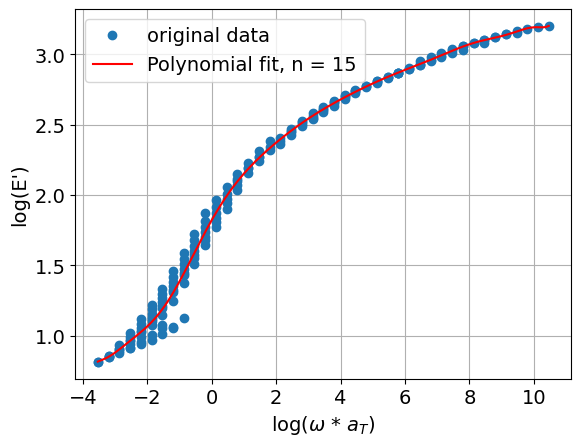

In [35]:
log_omega = []
log_Ep = []

for k in list(Ep_isotherm_shifted.keys()):
	log_omega.append(list(np.log10(Ep_isotherm_shifted[k][0])))
	log_Ep.append(list(np.log10(Ep_isotherm_shifted[k][1])))
x2, y2, xnew, ynew, poly_output, pfit = fit_poly_func(log_omega,log_Ep,num_terms)


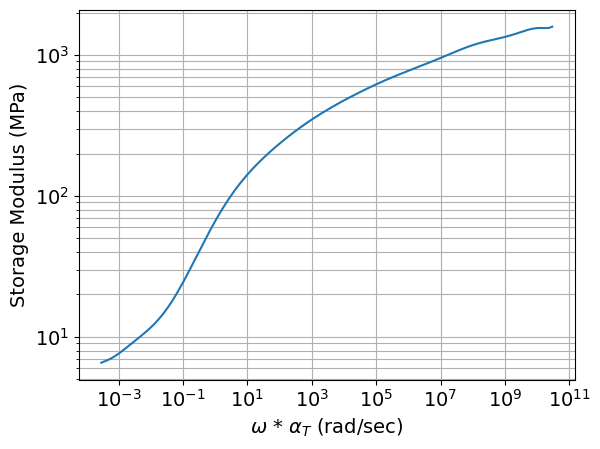

In [36]:
# Write out datapoints from fitted master curve function for convenience
xx = np.reshape(xnew,(np.shape(xnew)[0],1))
yy = np.reshape(ynew,(np.shape(ynew)[0],1))
# Get omega from log(omega)
xx = 10**xx
# Get E' from log(E')
yy = 10**yy
master_curve_pts = np.hstack([xx,yy])
plt.loglog(xx,yy)
plt.xlabel(r'$\omega$ * $\alpha_{T}$ (rad/sec)')
plt.ylabel("Storage Modulus (MPa)")
plt.grid(which='both')
with open(os.path.join(dir,'master_curve_Tref_' + T0 + '.csv'), "w") as f:
    writer = csv.writer(f, delimiter=",", lineterminator="\n")
    writer.writerows(master_curve_pts)

### Calculate continuous relaxation frequency spectrum, $h_s$

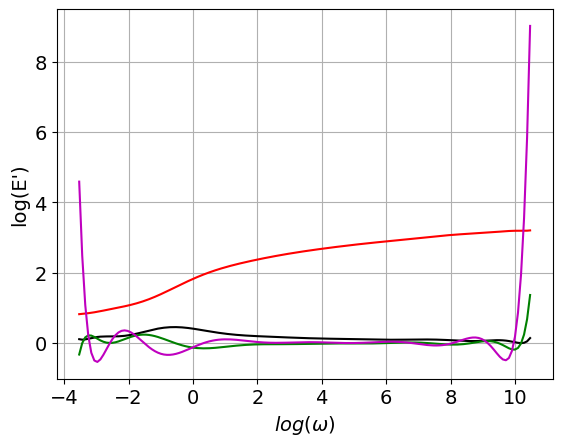

0.36771559713033264


Text(0.5, 1.0, 'Storage Modulus Polynomial Fit Overlay')

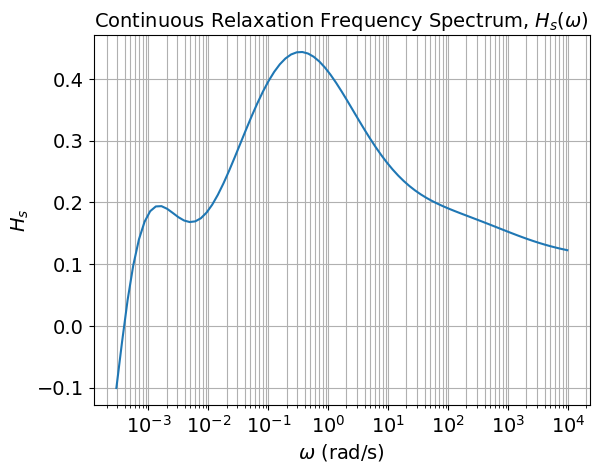

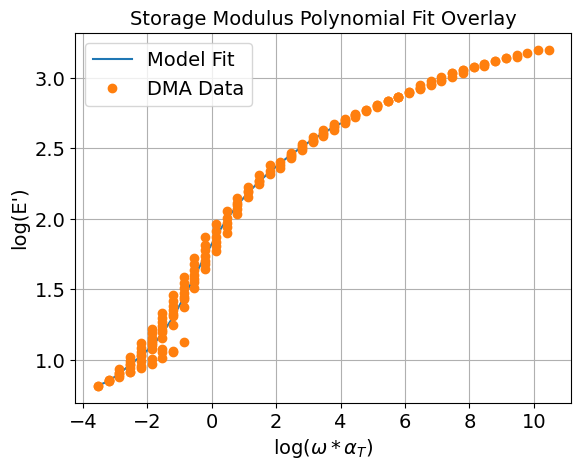

In [37]:
# Cutoff for log(w)
wlow   = 10**-4
whigh  = 10**4
w_full = 10**xnew
E_full = 10**ynew

# Extract total (instantaneous) and equilibrium (long term) storage modulii from master curve before truncation
E_total = E_full[-1]
E_eq = E_full[0]
fname = os.path.join(dir,'Eeq_E0.csv')
labels = ['Frequency (rad/s)', 'Long-Term Storage Modulus(MPA)','Frequency (rad/s)','Instantaneous Modulus (MPa)']
Eeq_E0 = [w_full[0],E_full[0],w_full[-1],E_full[-1]]

wlow_array = np.ones(np.shape(w_full)[0])*wlow
whigh_array = np.ones(np.shape(w_full)[0])*whigh
ww1 = np.abs(w_full - wlow_array)
ww2 = np.abs(w_full - whigh_array)
# Find index of wlow in w_full
ix = np.where(ww1 == ww1.min())
ix = ix[0][0]
# Find index of whigh in w_full
jx = np.where(ww2 == ww2.min())
jx = jx[0][0] + 1

# Trim master curve on either side
w = w_full[ix:jx]
logw = np.log10(w)
E = E_full[ix:jx]
logE = np.log10(E)

# Evaluate cumulative relaxation spectrum

# Get symbolic derivative of polynomial function
dpfit_dw = pfit.deriv()
ddpfit_ddw = dpfit_dw.deriv()
dddpfit_dddw = ddpfit_ddw.deriv()

# Plot approximation function and its derivatives
plt.figure(2)
plt.plot(np.log10(xx), pfit(np.log10(xx)), '-r')
plt.plot(np.log10(xx), dpfit_dw(np.log10(xx)), '-k')
plt.plot(np.log10(xx), ddpfit_ddw(np.log10(xx)), '-g')
plt.plot(np.log10(xx), dddpfit_dddw(np.log10(xx)), '-m')
plt.xlabel('$log(\omega)$')
plt.ylabel("log(E')")
plt.grid(which='both',axis='both')
plt.show()


x0 =logw
hs_new = dpfit_dw(x0) - (1/4) * (dpfit_dw(x0))**3 - (0.75/(np.log(10))) * dpfit_dw(x0) * ddpfit_ddw(x0) - (1/(4*(np.log(10))**2))*dddpfit_dddw(x0)
plt.figure(3)
plt.semilogx(10**logw,hs_new)
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('$H_s$')
plt.title('Continuous Relaxation Frequency Spectrum, $H_s(\omega)$')
plt.grid(which='both',axis='both')


# Print characteristic relaxation time based on highest non-equilibrium modulus value
ind_tau = list(hs_new).index(max(hs_new))
print(10**logw[ind_tau])


with open(fname, "w") as f:
    writer = csv.writer(f, delimiter=",", lineterminator="\n")
    writer.writerow(labels)
    writer.writerow(Eeq_E0)

# Calculate non-equilibrium modulus
E_neq  = E_total-E_eq    
mu_neq = E_neq/(2*(1+nu))
mu_eq  = E_eq/(2*(1+nu_rubbery))
w_min  = wlow
w_max  = whigh

# Plot truncated master curve fit overlaid on data
plt.figure(4)
E_storage_fitted_truncated = ynew[ix:jx]
plt.plot(logw,E_storage_fitted_truncated)
plt.xlabel(r'log($\omega * \alpha_T$)')
plt.ylabel("log(E')")
plt.grid(which='both',axis='both')
# Plot data
plt.plot(x2,y2,'o')
plt.legend(['Model Fit','DMA Data'])
plt.title('Storage Modulus Polynomial Fit Overlay')


### Cut off data that results in $h_s<0$

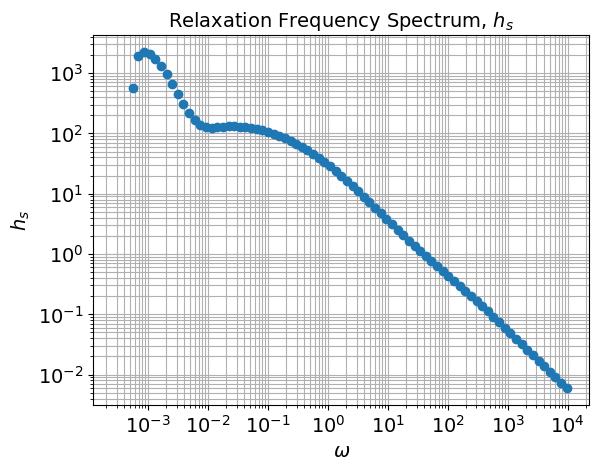

In [38]:
x = logw
hs = 10**(pfit(x)-x)*(dpfit_dw(x)-0.25*(dpfit_dw(x))**3-0.75/np.log10(10)*dpfit_dw(x)*ddpfit_ddw(x)-0.25/(np.log10(10))**2*dddpfit_dddw(x))

plt.figure(5)
plt.loglog(10**x,hs,'o')
plt.xlabel('$\omega$')
plt.ylabel('$h_s$')
plt.title('Relaxation Frequency Spectrum, $h_s$')
plt.grid(which='both',axis='both')


### Calculate cumulative relaxation frequency spectrum, $H_s$

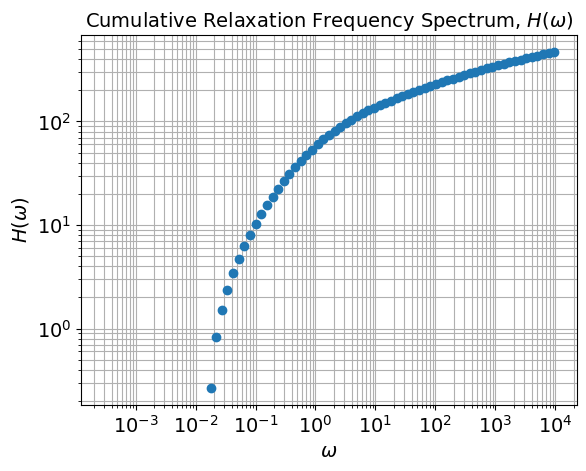

In [39]:
w_add0 = [0]
w_add0.extend(10**x)
hs_add0 = [0]
hs_add0.extend(hs)

Hs = integrate.cumulative_trapezoid(hs_add0,w_add0,initial=0)


plt.figure(6)
plt.loglog(w_add0,Hs,'o')
plt.xlabel('$\omega$')
plt.ylabel('$H(\omega)$')
plt.title('Cumulative Relaxation Frequency Spectrum, $H(\omega)$')
plt.grid(which='both',axis='both')

### Assume distribution of relaxation proesses and calculate/interpolate corresponding cumulative relaxation magnitude

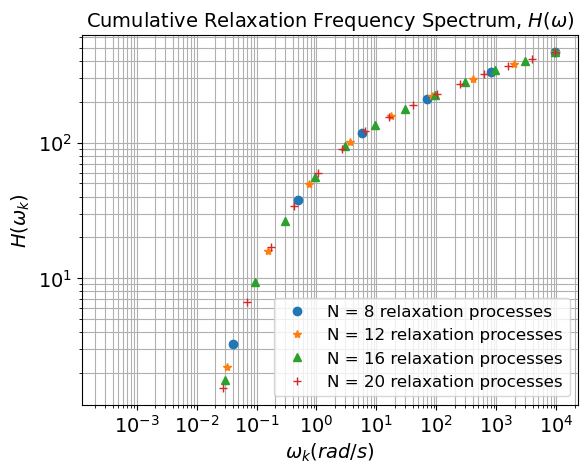

In [40]:
# Pick number of relaxation processes to investigate
N1 = 8
N2 = 12
N3 = 16
N4 = 20


k1 = np.linspace(1,N1,N1)
k2 = np.linspace(1,N2,N2)
k3 = np.linspace(1,N3,N3)
k4 = np.linspace(1,N4,N4)


# Reassign variables for convenience
w_max = np.max(w)
w_min = np.min(w)

# Assuming a power law distribution:
wk1 = w_min * (w_max/w_min) ** ((k1-1)/(N1-1))
wk2 = w_min * (w_max/w_min) ** ((k2-1)/(N2-1))
wk3 = w_min * (w_max/w_min) ** ((k3-1)/(N3-1))
wk4 = w_min * (w_max/w_min) ** ((k4-1)/(N4-1))

Hs = Hs[1:]
Hs_wk1 = np.interp(wk1,w,Hs)
Hs_wk2 = np.interp(wk2,w,Hs)
Hs_wk3 = np.interp(wk3,w,Hs)
Hs_wk4 = np.interp(wk4,w,Hs)

plt.figure(6)
plt.loglog(wk1,Hs_wk1,'o')
plt.loglog(wk2,Hs_wk2,'*')
plt.loglog(wk3,Hs_wk3,'^')
plt.loglog(wk4,Hs_wk4,'+')
plt.legend(['N = ' + str(N1) + ' relaxation processes','N = ' + str(N2) + ' relaxation processes',
            'N = ' + str(N3) + ' relaxation processes','N = ' + str(N4) + ' relaxation processes',],fontsize=12)
plt.title('Cumulative Relaxation Frequency Spectrum, $H(\omega)$')
plt.ylabel('$H(\omega_k)$')
plt.xlabel('$\omega_k (rad/s)$')
plt.grid(which='both',axis='both')


### Calculate discrete relaxation spectrum pairs $(\tau_k,\mu_k)$

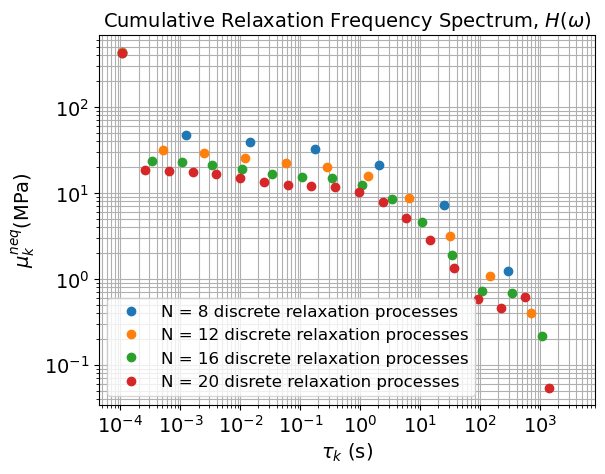

In [41]:
muk_1 = np.zeros(N1)
muk_1[0] = (1/2.7) * 0.5 * (Hs_wk1[1] + Hs_wk1[0])
for k in range(1,N1-1):
    muk_1[k] = (1/2.7) * 0.5 * (Hs_wk1[k+1] - Hs_wk1[k-1])
muk_1[N1-1] = mu_neq - np.sum(muk_1[0:N1])

muk_2 = np.zeros(N2)
muk_2[0] = (1/2.7) * (0.5 * Hs_wk2[1] + Hs_wk2[0])
for k in range(1,N2-1):
    muk_2[k] = (1/2.7) * 0.5 * (Hs_wk2[k+1] - Hs_wk2[k-1])
muk_2[N2-1] = mu_neq - np.sum(muk_2[0:N2])

muk_3 = np.zeros(N3)
muk_3[0] = (1/2.7) * 0.5 * (Hs_wk3[1] + Hs_wk3[0])
for k in range(1,N3-1):
    muk_3[k] = (1/2.7) * 0.5 * (Hs_wk3[k+1] - Hs_wk3[k-1])
muk_3[N3-1] = mu_neq - np.sum(muk_3[0:N3])

muk_4 = np.zeros(N4)
muk_4[0] = (1/2.7) * 0.5 * (Hs_wk4[1] + Hs_wk4[0])
for k in range(1,N4-1):
    muk_4[k] = (1/2.7) * 0.5 * (Hs_wk4[k+1] - Hs_wk4[k-1])
muk_4[N4-1] = mu_neq - np.sum(muk_4[0:N4])

plt.loglog(1/wk1,muk_1,'o')
plt.loglog(1/wk2,muk_2,'o')
plt.loglog(1/wk3,muk_3,'o')
plt.loglog(1/wk4,muk_4,'o')

plt.legend(['N = ' + str(N1) + ' discrete relaxation processes','N = ' + str(N2) + ' discrete relaxation processes',
            'N = ' + str(N3) + ' discrete relaxation processes','N = ' + str(N4) + ' disrete relaxation processes',],fontsize=12)
plt.title('Cumulative Relaxation Frequency Spectrum, $H(\omega)$')
plt.grid(which='both',axis='both')
plt.xlabel('$\\tau_k$ (s)')
plt.ylabel('$\mu_k^{neq}$(MPa)')
plt.show()

viscosity1=muk_1/wk1
viscosity2=muk_2/wk2
viscosity3=muk_3/wk3
viscosity4=muk_4/wk4

# print(viscosity1)
# print(viscosity2)
# print(viscosity3)
# print(viscosity4)


[[ 3.42894869e+03 -9.70411194e-01]
 [ 2.89290936e+02  1.22280144e+00]
 [ 2.44066777e+01  7.29884258e+00]
 [ 2.05912402e+00  2.11465174e+01]
 [ 1.73722610e-01  3.22254821e+01]
 [ 1.46564970e-02  3.97503483e+01]
 [ 1.23652820e-03  4.76051715e+01]
 [ 1.04322471e-04  4.41701022e+02]]
[[ 3.42894869e+03 -1.89774222e+00]
 [ 7.10914000e+02  4.05335135e-01]
 [ 1.47391740e+02  1.07187052e+00]
 [ 3.05583025e+01  3.13033443e+00]
 [ 6.33556434e+00  8.75340521e+00]
 [ 1.31353420e+00  1.58519479e+01]
 [ 2.72331241e-01  2.01711076e+01]
 [ 5.64616473e-02  2.21925961e+01]
 [ 1.17060298e-02  2.55993100e+01]
 [ 2.42697724e-03  2.95424561e+01]
 [ 5.03178161e-04  3.18437711e+01]
 [ 1.04322471e-04  4.33315382e+02]]
[[ 3.42894869e+03 -1.45025851e+00]
 [ 1.08153882e+03  2.19829073e-01]
 [ 3.41132610e+02  6.84574953e-01]
 [ 1.07598040e+02  7.27810380e-01]
 [ 3.39379408e+01  1.89234260e+00]
 [ 1.07045056e+01  4.57977297e+00]
 [ 3.37635216e+00  8.55941887e+00]
 [ 1.06494913e+00  1.24860810e+01]
 [ 3.35899988e-01 

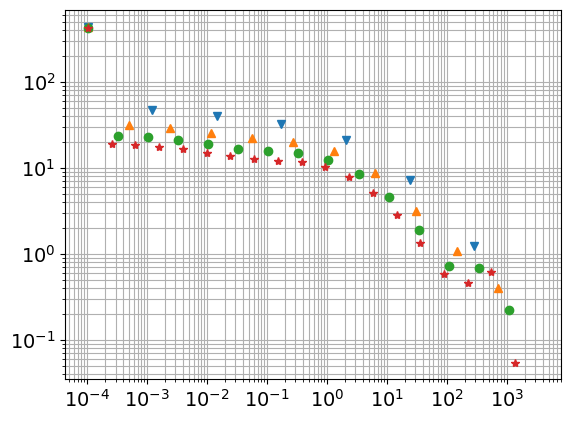

In [42]:
# Write out [tau,mu] pairs for fitting Prony series to relaxation spectrum
#wk_muk_1 = np.concatenate(np.reshape(np.asarray(wk1),np.asarray(wk1).shape[0],1),np.reshape(muk_1.shape[0],1),axis=1)

# N1 Processes
tau1 = 1/wk1
a1 = np.reshape(tau1,(np.shape(tau1)[0],1))
a2 = np.reshape(muk_1,(np.shape(muk_1)[0],1))
tauk_muk_1 = np.hstack([a1,a2])
print(tauk_muk_1)
plt.loglog(a1,a2,'v')
with open(os.path.join(dir,"tauk_muk_N1.csv"), "w") as f:
    writer = csv.writer(f, delimiter=",", lineterminator="\n")
    writer.writerows(tauk_muk_1)

# N2 Processes
tau2 = 1/wk2
a1 = np.reshape(tau2,(np.shape(tau2)[0],1))
a2 = np.reshape(muk_2,(np.shape(muk_2)[0],1))
tauk_muk_2 = np.hstack([a1,a2])
print(tauk_muk_2)
plt.loglog(a1,a2,'^')
with open(os.path.join(dir,"tauk_muk_N2.csv"), "w") as f:
    writer = csv.writer(f, delimiter=",", lineterminator="\n")
    writer.writerows(tauk_muk_2)

    
# N3 Processes
tau3 = 1/wk3
a1 = np.reshape(tau3,(np.shape(tau3)[0],1))
a2 = np.reshape(muk_3,(np.shape(muk_3)[0],1))
tauk_muk_3 = np.hstack([a1,a2])
print(tauk_muk_3)
plt.loglog(a1,a2,'o')
with open(os.path.join(dir,"tauk_muk_N3.csv"), "w") as f:
    writer = csv.writer(f, delimiter=",", lineterminator="\n")
    writer.writerows(tauk_muk_3)


# N4 Processes
tau4 = 1/wk4
a1 = np.reshape(tau4,(np.shape(tau4)[0],1))
a2 = np.reshape(muk_4,(np.shape(muk_4)[0],1))
tauk_muk_4 = np.hstack([a1,a2])
print(tauk_muk_4)
plt.loglog(a1,a2,'*')
plt.grid(which="both")
with open(os.path.join(dir,"tauk_muk_N4.csv"), "w") as f:
    writer = csv.writer(f, delimiter=",", lineterminator="\n")
    writer.writerows(tauk_muk_4)

### Recreate Master Curve Using Relaxation Spectra

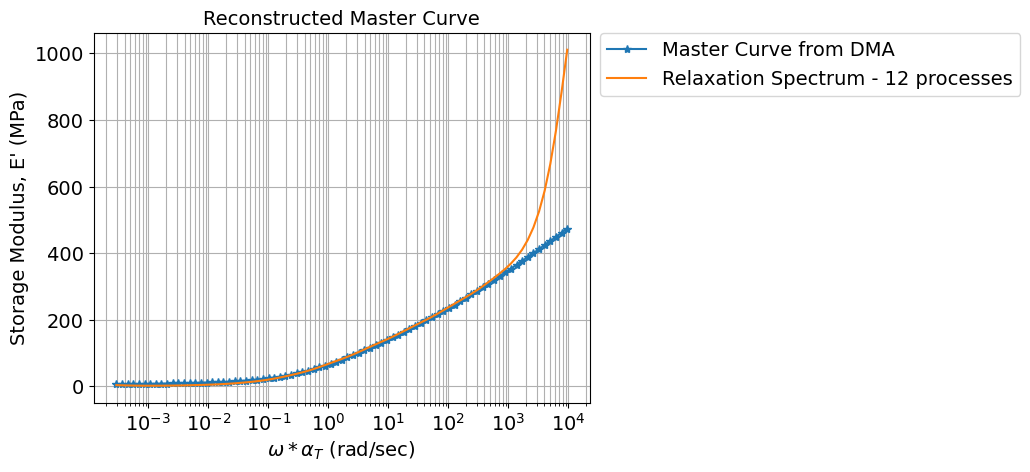

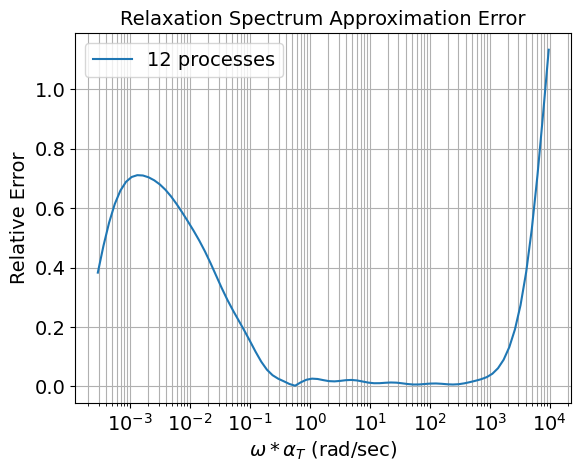

In [43]:
def recreate_MC_RS(tauk,muk,logw,logE):
        omega = 10**logw
        Eprime1 = E_eq
        Eprime2 = sum(2.7*muk[i]*(tauk[i]**2 * omega**2)/(1 + tauk[i]**2 * omega**2) for i in range(len(tauk)))
        E_storage_RS = Eprime1 + Eprime2
        # Plot truncated master curve (data)
        plt.figure(1)
        plt.semilogx(10**logw,10**logE,'-*')
        # Plot relaxation spectra (fit)
        plt.semilogx(10**logw,E_storage_RS)
        plt.xlabel(r'$\omega * \alpha_T$ (rad/sec)')
        plt.ylabel("Storage Modulus, E' (MPa)")
        plt.title('Reconstructed Master Curve')
        plt.legend(['Master Curve from DMA','Relaxation Spectrum - ' + str(len(tauk)) + ' processes'],bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
        plt.grid(which='both')
        plt.show()
        error = np.abs(E_storage_RS-10**logE)/10**logE
        plt.figure(2)
        plt.semilogx(10**logw,error)
        plt.title('Relaxation Spectrum Approximation Error')
        plt.xlabel(r'$\omega * \alpha_T$ (rad/sec)')
        plt.ylabel('Relative Error')
        plt.grid(which='both')
        plt.legend([str(len(tauk)) + ' processes'])
        plt.show()
        return E_storage_RS
 
E_storage_RS = recreate_MC_RS(tau2,muk_2,logw,logE)


### Fit Prony Series to Master Curve

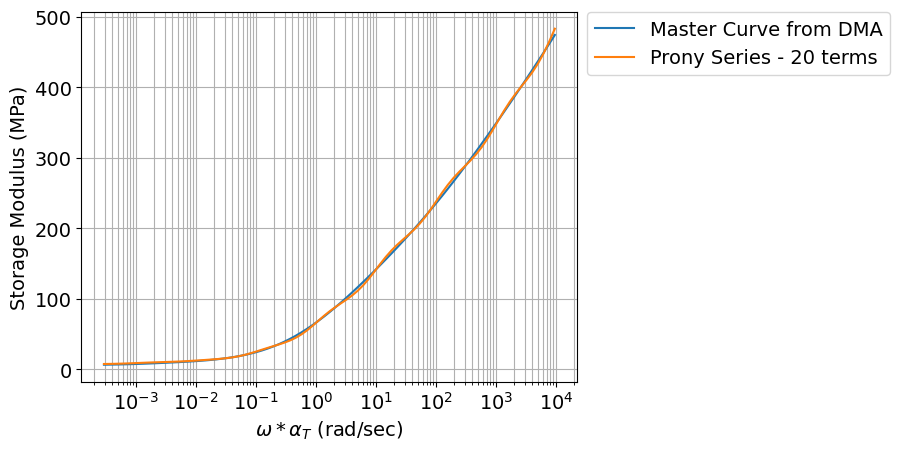

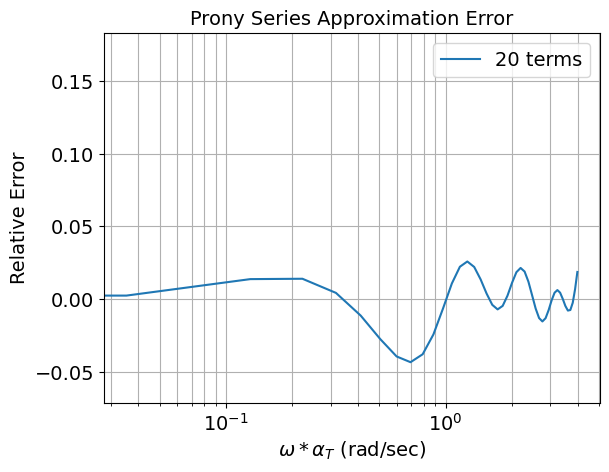

[[3.99870082e-02 0.00000000e+00 1.00000000e-10]
 [3.99870082e-02 0.00000000e+00 1.00000000e-09]
 [3.99870082e-02 0.00000000e+00 1.00000000e-08]
 [3.99869884e-02 0.00000000e+00 1.00000000e-07]
 [3.99866984e-02 0.00000000e+00 1.00000000e-06]
 [3.99565931e-02 0.00000000e+00 1.00000000e-05]
 [3.80357100e-02 0.00000000e+00 1.00000000e-04]
 [2.74900667e-02 0.00000000e+00 1.00000000e-03]
 [2.38329125e-02 0.00000000e+00 1.00000000e-02]
 [2.14205819e-02 0.00000000e+00 1.00000000e-01]
 [1.42357215e-02 0.00000000e+00 1.00000000e+00]
 [4.89419064e-03 0.00000000e+00 1.00000000e+01]
 [9.04288907e-04 0.00000000e+00 1.00000000e+02]
 [6.95726826e-04 0.00000000e+00 1.00000000e+03]
 [2.96819604e-05 0.00000000e+00 1.00000000e+04]
 [3.06288180e-04 0.00000000e+00 1.00000000e+05]
 [3.49146080e-04 0.00000000e+00 1.00000000e+06]
 [3.49570071e-04 0.00000000e+00 1.00000000e+07]
 [3.49569907e-04 0.00000000e+00 1.00000000e+08]
 [3.49568788e-04 0.00000000e+00 1.00000000e+09]]
0.9999999999999999


In [44]:
# DMA data
xdata = 10 ** logw
ydata = (10 ** logE)/E_total
 
# Establish time constants
p = []
for j in (range(0,num_prony_terms)):
    min_time = np.floor(-num_prony_terms/2)
    p = np.append(p,10**(min_time + int(j)))

# Initial guess at Prony series non-dimensional values
ei_0 = np.ones(p.shape[0],) * 0.5
# Create list of tuples for individual Prony terms for bounds
lst = np.ones(np.shape(p)[0])
bounds_list=[]
for i in range(len(lst)):
    bounds_list.append((0,1))
 
# Constraint 1: Sum of Prony terms <= 1 (Abaqus-specific)
def prony_leq1_constraint(ei):
    return 1.0 - sum((ei[i] ) for i in range(len(ei))) # >= 0
 
const_leq1 = {'type':'ineq','fun':prony_leq1_constraint}
 
# Concatenate constraints (if more than one)
all_const = [{'type':'eq','fun':prony_leq1_constraint}]
 
# Function to be minimized
def fun_relax(ei):
    Eprime1 = (1 - sum((ei[i]) for i in range(len(p))))
    Eprime2 = sum((ei[i] * p[i]**2 * np.power(xdata,2))/(1 + p[i]**2 * np.power(xdata,2)) for i in range(len(p)))
    ypred = (Eprime1 + Eprime2)
    ydata_arr = np.asarray(ydata)
    ypred_arr = np.asarray(ypred)
    rssq_error = 0
    for j in range(0,np.shape(ydata_arr)[0]):
        # See Abaqus manual for below error function definition
        rssq_error += abs(ypred_arr[j]-ydata_arr[j])**2/E_eq**2
    return rssq_error
 
# Call optimizer
optim = scipy.optimize.minimize(fun_relax,ei_0,constraints=all_const,bounds = bounds_list)
 
# Assign optimizer values to variable
ei = optim.x
 
# Evaluate optimized solution
def fun_eval(ei,p):
    Eprime1 = (1 - sum((ei[i]) for i in range(len(p))))
    Eprime2 = sum((ei[i] * p[i]**2 * np.power(xdata,2))/(1 + p[i]**2 * np.power(xdata,2)) for i in range(len(p)))
    Epred =  E_total * (Eprime1 + Eprime2)
    return Epred
 
# Calculate approximation relative error
def error(logw,logE,Epred):
        omega = 10**logw
        error = (10**np.log10(Epred)-10**logE)/10**logE
        return error
       
# Plot reconstructed master curve overlaid with data
plt.figure()
Epred = fun_eval(ei,p)
plt.semilogx(10**logw,10**logE)
plt.semilogx(10**logw,Epred)
plt.xlabel(r'$\omega * \alpha_T$ (rad/sec)')
plt.ylabel('Storage Modulus (MPa)')
plt.legend(['Master Curve from DMA', 'Prony Series - ' + str(num_prony_terms) + ' terms'],bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.grid(which='both')
plt.show()
 
# Plot error as a function of frequency for master curve approximation (at reference temperature)
plt.figure()
E_error = error(logw,logE,Epred)
plt.semilogx(logw,E_error)
plt.title('Prony Series Approximation Error')
plt.xlabel(r'$\omega * \alpha_T$ (rad/sec)')
plt.ylabel('Relative Error')
plt.legend([str(len(p)) + ' terms'])
plt.grid(which='both')
plt.show()
 
# Convert to shear storage modulus (IAW Abaqus)
gi = ei / (2.0 * (1.0 + nu))
# Ignore viscoelastic effects on bulk modulus
ki = np.zeros(np.shape(p))
 
gi = np.reshape(gi,(np.shape(gi)[0],1))
ki = np.reshape(ki,(np.shape(ki)[0],1))
p = np.reshape(p,(np.shape(p)[0],1))
prony_keyword = np.concatenate([gi,ki,p],axis=1)
 
 # Write out Prony series approximation
print(prony_keyword)
with open(os.path.join(dir,str(mat + "_prony_series_" + str(num_prony_terms) + "_Tref" + T0 + ".csv")), "w") as f:
    writer = csv.writer(f, delimiter=",", lineterminator="\n")
    writer.writerows(prony_keyword)

print(sum(ei))


### Use Prony Series to Plot Relaxation Modulus
$$
\tilde{E}_R(t) = E_0 - E_0\biggr[\sum^N_{i=1}e_i^p\biggr(1-e^{\frac{-t^*}{(\tau_i^p)}}\biggr)\biggr] = E_0 - E_0\biggr[\sum^N_{i=1}e_i^p\biggr(1-e^{\frac{-t}{(\alpha_T * \tau_i^p)}}\biggr)\biggr]
$$
where $\tilde{E}_R(t)$ is the "shifted" relaxation modulus which is explicitly dependent on time and implicitly dependendent on temperature (see $\alpha_T$), and:
$$
t^* = \frac{t}{\alpha_T(T)}
$$
where $t^*$ is a scaled timescale according to the temperature of the material.

Text(0, 0.5, 'Relaxation (Storage) Modulus (MPa)')

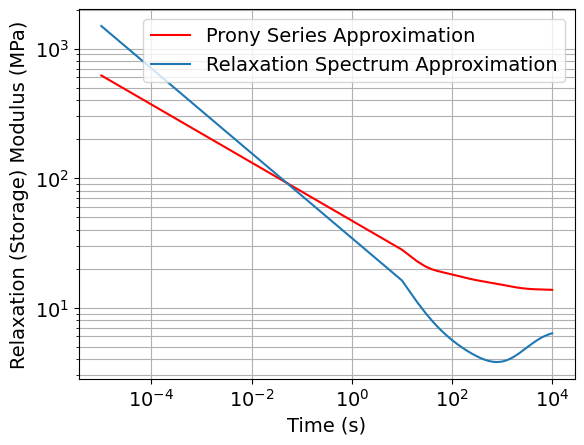

In [45]:
t = np.linspace(10**-5,10**4,1000)
 
# Assume constant temperature (@ reference temperature)
SF = 1
 
# Function for plotting relaxation modulus from Prony series approximation
def prony_relax(E_total,ei,p,t):
    #Er = E_total * (1 - sum(ei[k] *( 1 - np.exp(-t/(SF*p[k]))) for k in range(0,len(p))))
    Er = E_eq + E_total*sum(ei[k] *(np.exp(-t/(SF*p[k]))) for k in range(0,len(p)))
    return Er
   
# Function for plotting relaxation modulus from relaxation spectrum 
def spectrum_relax(E_eq,muk,tauk):
    Er = E_eq  + sum(2.7*muk[k] * np.exp(-t/(SF*tauk[k])) for k in range(0,len(tauk)))
    return Er

Er_prony = prony_relax(E_total,ei,p,t) 
Er_RS    = spectrum_relax(E_eq,muk_4,tau4)

plt.loglog(t,Er_prony,'-r',t,Er_RS)
plt.grid(which='both')
plt.legend(['Prony Series Approximation','Relaxation Spectrum Approximation'])
plt.xlabel('Time (s)')
plt.ylabel('Relaxation (Storage) Modulus (MPa)')

## Block 6: Fit WLF Parameters
$$
log(\alpha_T) = \frac{-C_1(T-T_{ref,MC})}{C2 + (T - T_{ref,MC})}
$$

C1 = 22.84350986091312
C2 = 214.44093857076604


Text(0.5, 1.0, 'WLF Shift Relationship ($T_{ref,MC} = $ 90C)')

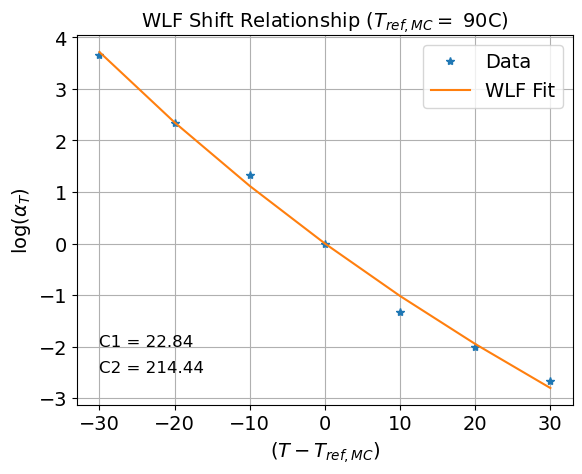

In [46]:
# Manually selected values picked from shift_factors
Tdiff = [-30,-20,-10,0,10,20,30]                   # (T - Tref,MC)
alpha = [3.66,2.33,1.33,0,-1.33,-2,-2.66]          # log(alpha) values


if TRS == 'WLF':

    x = np.asarray(Tdiff)
    y = np.asarray(alpha)

    def residual(C):
        return y + (1 * ((C[0] * x)/(C[1] + x)))

    def WLF_func(C):
        return (-1 * ((C[0] * x)/(C[1] + x)))

    C0 = np.array([100.0,200.0])
    parameters = least_squares(residual,C0)
    print('C1 = ' + str(parameters.x[0]))
    print('C2 = ' + str(parameters.x[1]))
    ypred = WLF_func(parameters.x)
    C1 = parameters.x[0]
    C2 = parameters.x[1]

# Plot C1, C2 fit
plt.figure()
plt.plot(Tdiff,y,'*')
plt.plot(Tdiff,ypred)  
plt.grid(which='both')
plt.text(-30,-2, str('C1 = ' + str(round(C1,2))), fontsize = 12)
plt.text(-30,-2.5, str('C2 = ' + str(round(C2,2))), fontsize = 12)
plt.legend(['Data','WLF Fit'])
plt.ylabel(r'log($\alpha_T$)')
plt.xlabel(r'$(T-T_{ref,MC})$')  
plt.title(r'WLF Shift Relationship ($T_{ref,MC} = $ ' + T0 + ')')

## Block 7: Heat Transfer Functions and WLF Shift Factor Calculations
#### Note: Right now this is set for a constant material temperature (Tval - see below). If you want to change to a convection-dominated lumped capacitance cooling problem, you will need to udpate and verify the thermal properties in the property block (Block 1) at the top of the file.

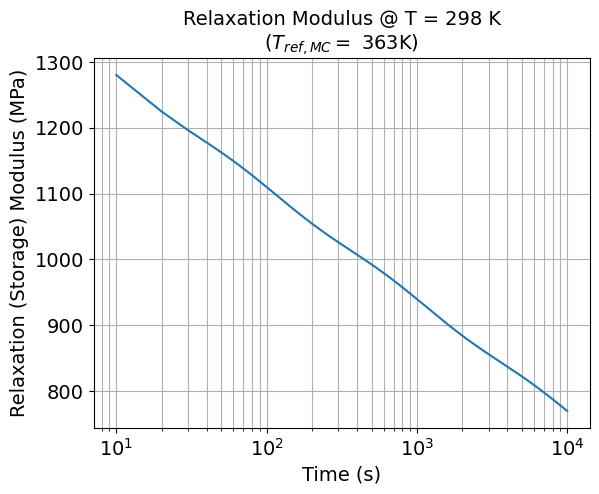

In [48]:
T_t0      = 423             # Temperature @ t=0,K
Tref      = 273             # Reference temperature for CTE, K
T_ref_MC  = 363             # Reference temperature for master curve, K
T_ref_CTE = 298             # Reference temperature for CTE, K
Tinf      = 298             # Ambient temperature
Thot      = T_t0            # Temperature to which entire part is heated
cp        = 1.4E9           # specific heat, mJ/(tonne*K)
k         = 0.16            # thermal conductivity, mW/(mm*K)
rho       = 1.1E-9          # density, tonne/mm^3

#CTE     = 600E-6          # CTE (temperature-independent), 1/K 
CTE       = np.array([[273,303,308,473],
                      [300E-6,300E-6,600E-6,600E-6]]) # Array of [Temp,CTE]
h         = 0.01           # convective heat transfer coefficient, mW/(mm^2*K)
tau_c     = 100

# Relaxation spectrum parameters (using master curve generated at Tref=90C) and other viscoelastic parameters
nu_g      = nu           # glassy Poisson's ratio
nu_r      = 0.5          # rubbery Poisson's ratio
tau_visco = 10**-4       # characteristic relaxation time, s
mu_eq     = E_eq/(2 * (1 + nu_r))
tau_k     = [9E10,5.99E9,3.95E8,2.61E7,1.72E6,1.13E5,7.49E3,4.94E2,3.26E1,2.15,1.42E-1,9.36E-3]     # relaxation time constants, s
mu_neqk   = [1.36,4.399,19.5,38.7,48.4,47.2,54.5,65.7,72.8,78.8,103,55.6]         # MPa

Tval = 298

# Lumped capacitance model to calculate T(t)
def calculateT(T0,tau_c,t):
    T = (T0 - Tinf)*np.exp(-t/tau_c) + Tinf
    return T

# Calculate CTE value at given temperature
def calculate_CTE(T):
    CTE_val = np.interp(T,CTE[0],CTE[1])
    return CTE_val 

# WLF Shift factor equation
def calculate_alpha(C1,C2,T0,Tref_MC,tau_c,t):
    T = calculateT(T0,Tinf,tau_c,t)
    SF = 10**((-C1*(T-Tref_MC))/(C2+T-Tref_MC))
    return SF, T

# WLF Shift factor equation (CONSTANT TEMPERATURE)
def calculate_alpha_constT(C1,C2,Tref,Tval):
    T = Tval
    SF = 10**((-C1*(T-Tref))/(C2+T-Tref))
    return SF, T    

# Calculate relaxation modulus using Prony series (VARIABLE TEMPERATURE)
def calculate_relaxation(C1,C2,Tref_MC,tau_c,E_eq,p,gi,nu_g,nu_r,t,T):
    Ep = []
    SF, T = calculate_alpha(C1,C2,T_t0,Tref_MC,tau_c,t)
    # See Eq. 34 Overleaf doc
    Er = E_total - E_total * sum(ei[k] * np.exp(-t/(SF*p[k])) for k in range(0,len(p)))
    return Er, SF 

# Calculate relaxation modulus using Prony series (CONSTANT TEMPERATURE)
def calculate_relaxation_constT(C1,C2,T_ref_MC,p,ei,t):
    Ep = []
    SF,T = calculate_alpha_constT(C1,C2,T_ref_MC,Tval)
    Er = E_total - E_total * sum(ei[k] *( 1 - np.exp(-t/(SF*p[k]))) for k in range(0,len(p)))
    return Er, SF 

T_dielectric   = calculateT(T_t0,tau_c,t)
Er, SF         = calculate_relaxation_constT(C1,C2,T_ref_MC,p,ei,t)

plt.semilogx(t[1:-1],Er[1:-1])
plt.grid(which='both')
plt.xlabel('Time (s)')
plt.ylabel('Relaxation (Storage) Modulus (MPa)')
plt.title(r'Relaxation Modulus @ T = ' + str(Tval) + ' K\n' + r'$(T_{ref,MC} = $ ' + str(int(T0[0:-1])+273) + 'K)')
plt.show()


## Block 8: Write Out Prony Series and WLF Keywords in Abaqus Input Format

In [158]:
# Write Abaqus material keyword
fid = mat + '_linear_visco_Tref' + T0 + '.inp'
filename = os.path.join(dir,fid)

def format_list_to_scientific(lst):
    return [f"{x:.2e}" for x in lst]

prony_out = []
for i in range(0,np.shape(prony_keyword)[0]):
    vals = list(prony_keyword[i])
    formatted_vals = format_list_to_scientific(vals)
    prony_out.append(formatted_vals)


def write_list(f, lst, n):
    for i in range(0, len(lst)):
        item = lst[i]
        f.write(",".join(str(val) for val in item) + "\n")
    
with open(filename, 'w') as f:
    line1 = str('*Material, name=' + mat)
    line2 = '*Elastic,moduli=INSTANTANEOUS'
    line3 = str(round(E_total,2)) + ',' + str(nu)  
    line4 = '*Viscoelastic,time=Prony' 
    line5 = '*TRS,DEFINITION = WLF'
    line6 = str(int(T0[0:-1])+273) + ',' + str(round(C1,2)) + ',' + str(round(C2,2))
    f.write('{}\n{}\n{}\n{}\n'.format(line1,line2,line3,line4))
    write_list(f,prony_out,1)
    f.write('{}\n{}'.format(line5,line6))